# Classical ML 

Four tasks, four classifiers, GridSearchCV (5-fold) on train only.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
FEAT = ROOT / 'features'
RES = ROOT / 'results'
FIG = ROOT / 'figures'
RES.mkdir(exist_ok=True)

OWNER = 'Pedro'
META_COLS = {
    'participant', 'context', 'session', 'split', 'window_idx', 'label_person',
    'label_context', 'participant_id', 'label_owner', 'label_context_bin',
    'cross_session_eligible', 'has_both_contexts', 'array_idx',
}

train_df = pd.read_csv(FEAT / 'feature_matrix_train.csv')
test_df = pd.read_csv(FEAT / 'feature_matrix_test.csv')
feat_cols = [c for c in train_df.columns if c not in META_COLS]

MODELS = {
    'Decision Tree': (DecisionTreeClassifier(random_state=42),
                      {'max_depth': [5, 10, 20, None], 'min_samples_leaf': [1, 5, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=42, n_jobs=-1),
                      {'n_estimators': [100], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 5]}),
    'k-NN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 10, 15]}),
    'SVM (RBF)': (SVC(probability=True, random_state=42),
                  {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}),
}

In [2]:
def eval_binary(y_true, y_pred, y_prob):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
    }
    out['roc_auc'] = roc_auc_score(y_true, y_prob[:, 1]) if len(np.unique(y_true)) == 2 else np.nan
    return out


def get_task_data(task_id):
    if task_id == 1:
        tr = train_df[(train_df['context'] == 'normal') & train_df['cross_session_eligible']]
        te = test_df[(test_df['context'] == 'normal') & test_df['cross_session_eligible']]
        return tr, te, tr['label_owner'], te['label_owner'], 'binary'
    if task_id == 2:
        tr = train_df[(train_df['context'] == 'normal') & train_df['cross_session_eligible']]
        te = test_df[(test_df['context'] == 'normal') & test_df['cross_session_eligible']]
        return tr, te, tr['label_person'], te['label_person'], 'multiclass'
    if task_id == 3:
        tr = train_df[train_df['has_both_contexts']]
        te = test_df[test_df['has_both_contexts']]
        return tr, te, tr['label_context_bin'], te['label_context_bin'], 'binary'
    raise ValueError(task_id)


results = []
best_models = {}

for task_id, task_name in [(1, 'Owner authentication'), (2, 'Person identification'), (3, 'Context classification')]:
    tr, te, y_tr, y_te, task_type = get_task_data(task_id)
    print(f'\n=== {task_name} ===')
    print(f'Train windows: {len(tr)}, Test windows: {len(te)}')
    print('Train balance:\n', y_tr.value_counts())
    print('Test balance:\n', y_te.value_counts())

    X_tr, X_te = tr[feat_cols], te[feat_cols]
    scaler = StandardScaler()
    best_score, best_name, best_clf, best_pred, best_prob = -1, None, None, None, None
    best_scaler = None

    for name, (est, grid) in MODELS.items():
        scale = name in ('k-NN', 'SVM (RBF)')
        Xtr = scaler.fit_transform(X_tr) if scale else X_tr.values
        Xte = scaler.transform(X_te) if scale else X_te.values
        gs = GridSearchCV(est, grid, cv=5, scoring='accuracy', n_jobs=-1)
        gs.fit(Xtr, y_tr)
        pred = gs.predict(Xte)
        prob = gs.predict_proba(Xte)
        metrics = eval_binary(y_te, pred, prob) if task_type == 'binary' else {
            'accuracy': accuracy_score(y_te, pred),
            'macro_f1': f1_score(y_te, pred, average='macro', zero_division=0),
        }
        metrics.update({'task': task_name, 'model': name, 'best_params': str(gs.best_params_)})
        results.append(metrics)
        print(f"  {name}: acc={metrics['accuracy']:.3f}")
        if metrics['accuracy'] > best_score:
            best_score, best_name = metrics['accuracy'], name
            best_clf, best_pred, best_prob = gs.best_estimator_, pred, prob
            best_scaler = scaler if scale else None

    best_models[task_id] = (best_name, best_clf, best_scaler, tr, te, y_tr, y_te, best_pred, best_prob)
    print(f'  >> Best: {best_name} ({best_score:.3f})')


=== Owner authentication ===
Train windows: 1432, Test windows: 716
Train balance:
 label_owner
0    1074
1     358
Name: count, dtype: int64
Test balance:
 label_owner
0    537
1    179
Name: count, dtype: int64
  Decision Tree: acc=0.939
  Random Forest: acc=1.000
  k-NN: acc=1.000
  SVM (RBF): acc=0.874
  >> Best: Random Forest (1.000)

=== Person identification ===
Train windows: 1432, Test windows: 716
Train balance:
 label_person
Darius    358
Jun       358
Oana      358
Pedro     358
Name: count, dtype: int64
Test balance:
 label_person
Darius    179
Jun       179
Oana      179
Pedro     179
Name: count, dtype: int64
  Decision Tree: acc=0.837
  Random Forest: acc=0.986
  k-NN: acc=0.996
  SVM (RBF): acc=0.994
  >> Best: k-NN (0.996)

=== Context classification ===
Train windows: 2141, Test windows: 1429
Train balance:
 label_context_bin
0    1432
1     709
Name: count, dtype: int64
Test balance:
 label_context_bin
0    716
1    713
Name: count, dtype: int64
  Decision Tree: ac

In [3]:
# Task 4: cross-context robustness (best task-1 model)
t1_name, t1_clf, t1_scaler, _, _, _, _, _, _ = best_models[1]
te_normal = test_df[(test_df['context'] == 'normal') & test_df['cross_session_eligible']]
te_crowded = test_df[test_df['context'] == 'crowded']

print('\n=== Cross-context robustness ===')
for subset_name, te_sub in [('normal_test', te_normal), ('crowded_test', te_crowded)]:
    Xte = t1_scaler.transform(te_sub[feat_cols]) if t1_scaler else te_sub[feat_cols].values
    pred = t1_clf.predict(Xte)
    prob = t1_clf.predict_proba(Xte)
    m = eval_binary(te_sub['label_owner'], pred, prob)
    m.update({'task': 'Cross-context robustness', 'model': t1_name, 'subset': subset_name, 'best_params': 'from task 1'})
    results.append(m)
    print(f"  {subset_name}: n={len(te_sub)} acc={m['accuracy']:.3f} f1={m['f1']:.3f}")

res_df = pd.DataFrame(results)
res_df.to_csv(RES / 'classical_ml_results.csv', index=False)
res_df


=== Cross-context robustness ===
  normal_test: n=716 acc=1.000 f1=1.000
  crowded_test: n=1054 acc=0.898 f1=0.651


,accuracy,f1,precision,recall,roc_auc,task,model,best_params,macro_f1,subset
0,0.938547,0.890547,0.802691,1.000000,0.959032,Owner authentication,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 1}",NaN,NaN
1,1.000000,1.000000,1.000000,1.000000,1.000000,Owner authentication,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 5, 'n_es...",NaN,NaN
2,1.000000,1.000000,1.000000,1.000000,1.000000,Owner authentication,k-NN,{'n_neighbors': 5},NaN,NaN
3,0.874302,0.664179,1.000000,0.497207,1.000000,Owner authentication,SVM (RBF),"{'C': 0.1, 'gamma': 'scale'}",NaN,NaN
4,0.836592,NaN,NaN,NaN,NaN,Person identification,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 5}",0.830928,NaN
5,0.986034,NaN,NaN,NaN,NaN,Person identification,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.986074,NaN
6,0.995810,NaN,NaN,NaN,NaN,Person identification,k-NN,{'n_neighbors': 5},0.995810,NaN
7,0.994413,NaN,NaN,NaN,NaN,Person identification,SVM (RBF),"{'C': 0.1, 'gamma': 'scale'}",0.994425,NaN
8,0.724283,0.632463,0.944290,0.475456,0.727755,Context classification,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 10}",NaN,NaN
9,0.875437,0.857372,1.000000,0.750351,0.989491,Context classification,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 5, 'n_es...",NaN,NaN


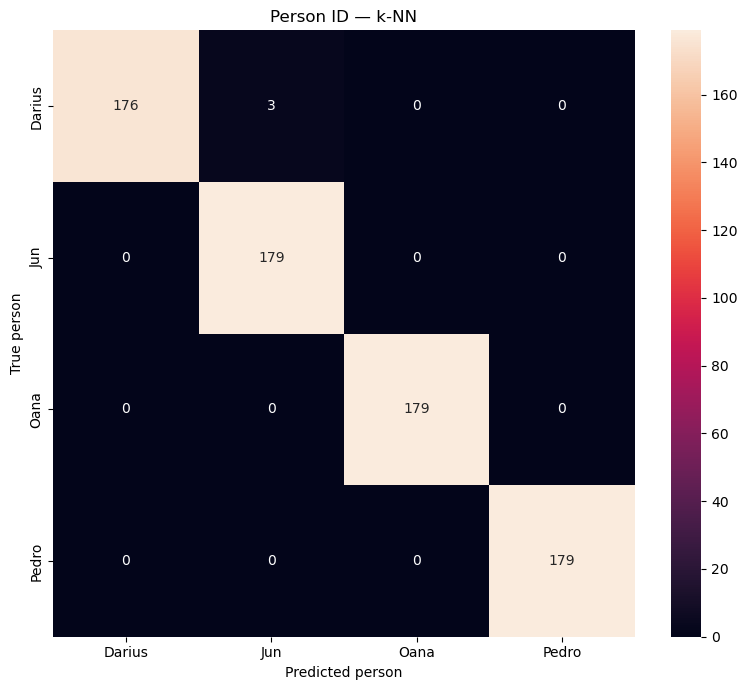

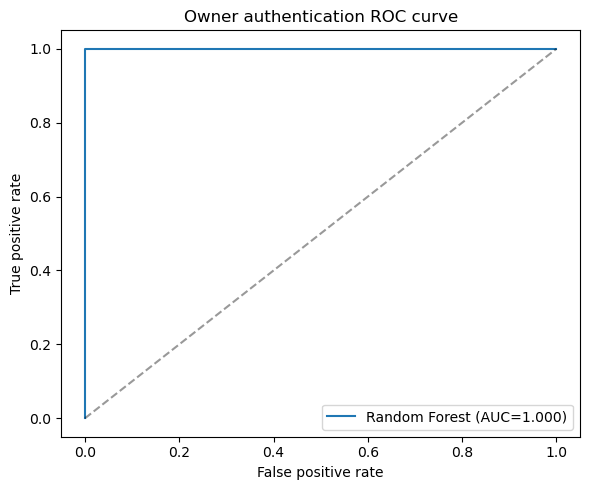

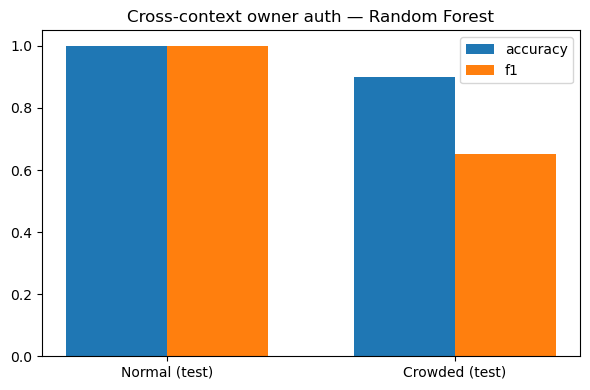


Best model per task:
  Owner authentication: Random Forest (acc=1.000)
  Person identification: k-NN (acc=0.996)
  Context classification: SVM (RBF) (acc=0.943)


In [4]:
# Figures
_, _, _, _, te2, _, y_te2, pred2, _ = best_models[2]
labels2 = sorted(y_te2.unique())
cm = confusion_matrix(y_te2, pred2, labels=labels2)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels2, yticklabels=labels2, ax=ax)
ax.set_xlabel('Predicted person')
ax.set_ylabel('True person')
ax.set_title(f'Person ID — {best_models[2][0]}')
fig.tight_layout()
fig.savefig(FIG / 'fig12_confusion_matrix_person_id.png', dpi=150)
plt.show()

_, _, _, _, te1, _, y_te1, _, prob1 = best_models[1]
fpr, tpr, _ = roc_curve(y_te1, prob1[:, 1])
auc = roc_auc_score(y_te1, prob1[:, 1])
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{best_models[1][0]} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('Owner authentication ROC curve')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig13_roc_owner_auth.png', dpi=150)
plt.show()

t4 = res_df[res_df['task'] == 'Cross-context robustness']
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
for i, metric in enumerate(['accuracy', 'f1']):
    vals = [t4.loc[t4['subset'] == s, metric].iloc[0] for s in ['normal_test', 'crowded_test']]
    ax.bar(x + i * 0.35, vals, 0.35, label=metric)
ax.set_xticks(x + 0.175)
ax.set_xticklabels(['Normal (test)', 'Crowded (test)'])
ax.set_ylim(0, 1.05)
ax.set_title(f'Cross-context owner auth — {t1_name}')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig14_cross_context_normal_vs_crowded.png', dpi=150)
plt.show()

print('\nBest model per task:')
for name in ['Owner authentication', 'Person identification', 'Context classification']:
    sub = res_df[res_df['task'] == name]
    best = sub.loc[sub['accuracy'].idxmax()]
    print(f"  {name}: {best['model']} (acc={best['accuracy']:.3f})")